In [26]:
import pandas as pd
import datetime as datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
data= pd.read_csv("Sleep_Data_Sampled.csv")
df= pd.DataFrame(data)
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14996,14997,Female,59,Nurse,8.00,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14997,14998,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
14998,14999,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [41]:
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy
5,6,Male,33,Doctor,6.90,7,50,6,Normal Weight,120/80,69,7500,Healthy
6,7,Male,44,Engineer,7.85,8,45,4,Normal,125/80,65,5000,Healthy
7,8,Male,40,Engineer,8.05,8,52,4,Normal,120/80,68,6500,Healthy
8,9,Male,36,Lawyer,6.85,7,60,6,Normal,130/85,71,6500,Healthy
9,10,Male,40,Engineer,7.15,7,58,6,Normal Weight,130/85,70,6500,Healthy


In [42]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.130667,6.997327,7.131267,59.925000,5.654800,70.857533,6795.080000
std,4330.271354,6.840091,0.615187,1.053111,16.814374,1.393568,3.614836,1329.706484
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,3750.750000,40.000000,6.500000,6.000000,45.000000,4.000000,68.000000,6000.000000
50%,7500.500000,44.000000,7.000000,7.000000,60.000000,6.000000,70.000000,6500.000000
75%,11250.250000,48.000000,7.450000,8.000000,75.000000,6.000000,72.000000,7600.000000
max,15000.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                15000 non-null  int64  
 1   Gender                   15000 non-null  object 
 2   Age                      15000 non-null  int64  
 3   Occupation               15000 non-null  object 
 4   Sleep Duration           15000 non-null  float64
 5   Quality of Sleep         15000 non-null  int64  
 6   Physical Activity Level  15000 non-null  int64  
 7   Stress Level             15000 non-null  int64  
 8   BMI Category             15000 non-null  object 
 9   Blood Pressure           15000 non-null  object 
 10  Heart Rate               15000 non-null  int64  
 11  Daily Steps              15000 non-null  int64  
 12  Sleep Disorder           15000 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usage: 1.5+ MB


In [44]:
print(df.nunique())
print("Duplicates:", df.duplicated().sum())


Person ID                  15000
Gender                         2
Age                           33
Occupation                    11
Sleep Duration                55
Quality of Sleep               6
Physical Activity Level       37
Stress Level                   6
BMI Category                   4
Blood Pressure                25
Heart Rate                    22
Daily Steps                   80
Sleep Disorder                 3
dtype: int64
Duplicates: 0


In [29]:
print(df.shape)


(15000, 13)


In [45]:
#There's no na values

df.isna().sum()


Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [46]:
#Detecting Outliers
summary = []

for col in df.select_dtypes(include=['number']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    summary.append({
        'Column': col,
        'Outlier Count': count,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

                    Column  Outlier Count  Lower Bound  Upper Bound
0                Person ID              0     -7498.50     22499.50
1                      Age              1        28.00        60.00
2           Sleep Duration              0         5.07         8.88
3         Quality of Sleep              0         3.00        11.00
4  Physical Activity Level              0         0.00       120.00
5             Stress Level              0         1.00         9.00
6               Heart Rate            479        62.00        78.00
7              Daily Steps             55      3600.00     10000.00


In [47]:
#Feature engineering
df['Activity_Per_Step'] = df['Physical Activity Level'] / df['Daily Steps']
df['Stress_Per_Age'] = df['Stress Level'] / df['Age']
df['Sleep_Efficiency'] = df['Quality of Sleep'] / df['Sleep Duration']
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Activity_Per_Step,Stress_Per_Age,Sleep_Efficiency
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy,0.007042,0.200000,1.052632
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy,0.007429,0.095238,1.159420
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy,0.010820,0.176471,1.007194
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy,0.008000,0.218750,0.869565
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy,0.009231,0.162162,1.021898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,0.010714,0.050847,1.111111
14996,14997,Female,59,Nurse,8.00,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,0.010714,0.050847,1.125000
14997,14998,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,0.010714,0.050847,1.111111
14998,14999,Female,59,Nurse,8.10,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,0.010714,0.050847,1.111111


In [48]:
print(df.corr(numeric_only=True)['Quality of Sleep'].sort_values(ascending=False))


Quality of Sleep           1.000000
Sleep Duration             0.871070
Sleep_Efficiency           0.854512
Age                        0.382186
Physical Activity Level    0.381601
Activity_Per_Step          0.371228
Daily Steps                0.188875
Person ID                 -0.423943
Heart Rate                -0.451876
Stress_Per_Age            -0.749714
Stress Level              -0.785485
Name: Quality of Sleep, dtype: float64


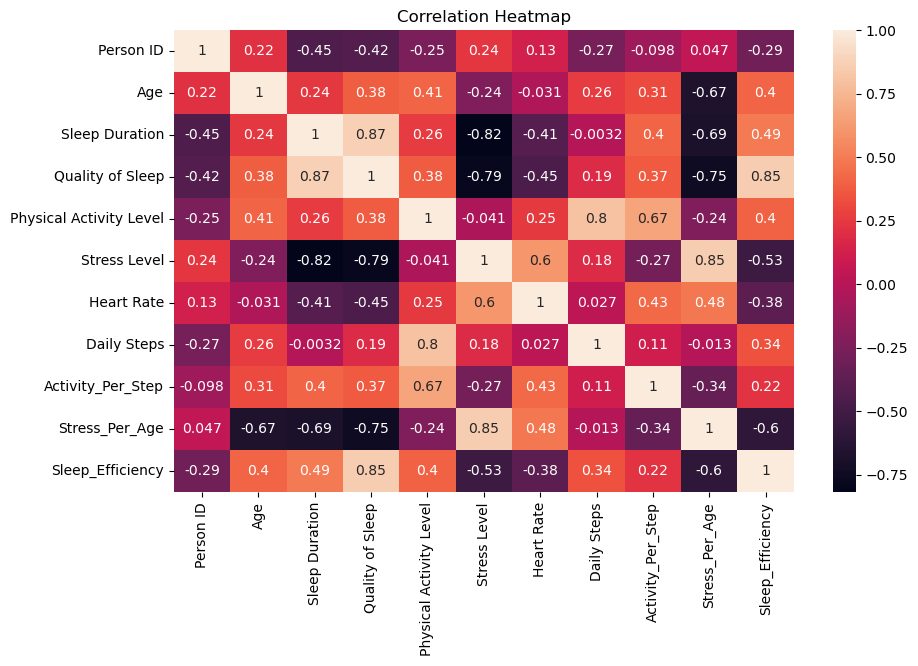

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

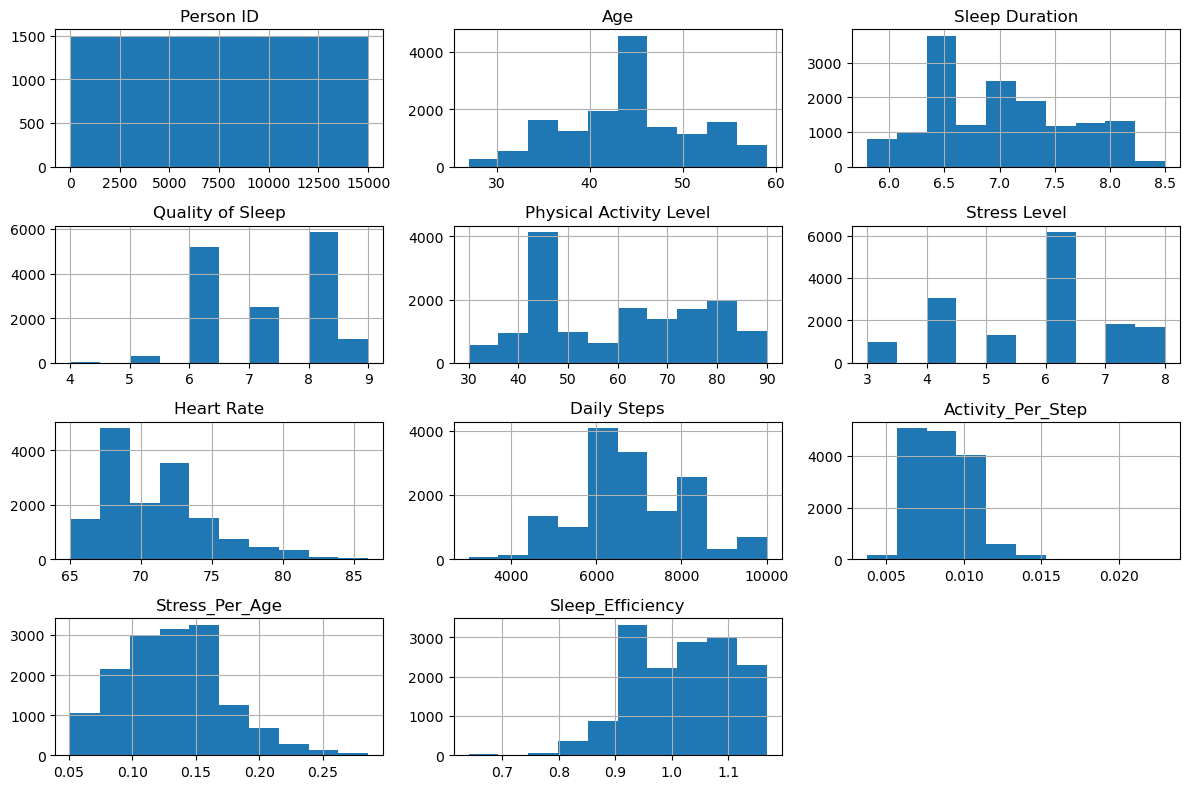

In [34]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

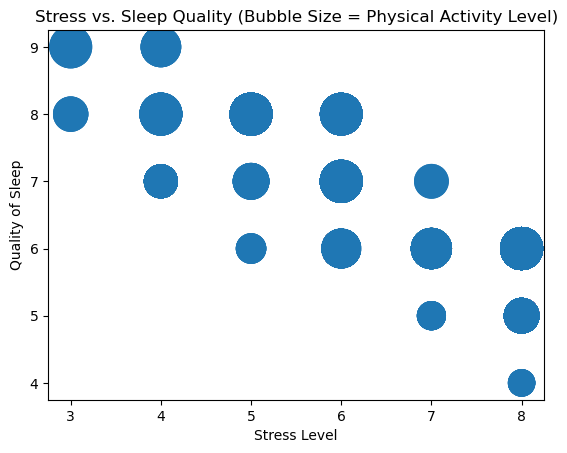

In [36]:
plt.scatter(
    df['Stress Level'],
    df['Quality of Sleep'],
    s=df['Physical Activity Level']*10
)

plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.title("Stress vs. Sleep Quality (Bubble Size = Physical Activity Level)")

plt.show()